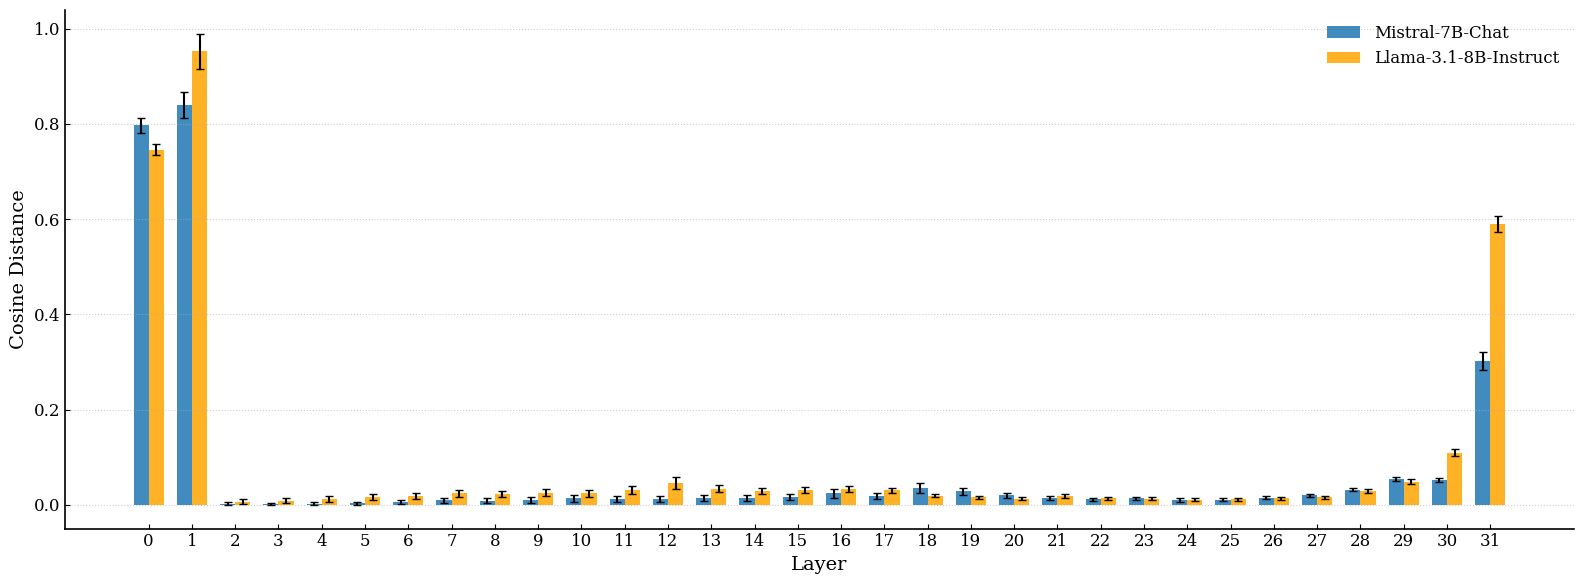

In [329]:
import matplotlib.pyplot as plt
import numpy as np
import re

# Your raw text data
mistral_data_raw = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7969 [Std:] 0.0162
[Layer:] 1 | Cosine Distance [Mean:] 0.8398 [Std:] 0.0272
[Layer:] 2 | Cosine Distance [Mean:] 0.0020 [Std:] 0.0027
[Layer:] 3 | Cosine Distance [Mean:] 0.0015 [Std:] 0.0020
[Layer:] 4 | Cosine Distance [Mean:] 0.0021 [Std:] 0.0027
[Layer:] 5 | Cosine Distance [Mean:] 0.0031 [Std:] 0.0034
[Layer:] 6 | Cosine Distance [Mean:] 0.0054 [Std:] 0.0046
[Layer:] 7 | Cosine Distance [Mean:] 0.0088 [Std:] 0.0054
[Layer:] 8 | Cosine Distance [Mean:] 0.0087 [Std:] 0.0053
[Layer:] 9 | Cosine Distance [Mean:] 0.0095 [Std:] 0.0056
[Layer:] 10 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0077
[Layer:] 11 | Cosine Distance [Mean:] 0.0122 [Std:] 0.0067
[Layer:] 12 | Cosine Distance [Mean:] 0.0117 [Std:] 0.0067
[Layer:] 13 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0066
[Layer:] 14 | Cosine Distance [Mean:] 0.0130 [Std:] 0.0063
[Layer:] 15 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0067
[Layer:] 16 | Cosine Distance [Mean:] 0.0238 [Std:] 0.0092
[Layer:] 17 | Cosine Distance [Mean:] 0.0181 [Std:] 0.0064
[Layer:] 18 | Cosine Distance [Mean:] 0.0342 [Std:] 0.0105
[Layer:] 19 | Cosine Distance [Mean:] 0.0283 [Std:] 0.0074
[Layer:] 20 | Cosine Distance [Mean:] 0.0193 [Std:] 0.0056
[Layer:] 21 | Cosine Distance [Mean:] 0.0133 [Std:] 0.0040
[Layer:] 22 | Cosine Distance [Mean:] 0.0112 [Std:] 0.0037
[Layer:] 23 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0040
[Layer:] 24 | Cosine Distance [Mean:] 0.0098 [Std:] 0.0036
[Layer:] 25 | Cosine Distance [Mean:] 0.0102 [Std:] 0.0035
[Layer:] 26 | Cosine Distance [Mean:] 0.0150 [Std:] 0.0034
[Layer:] 27 | Cosine Distance [Mean:] 0.0198 [Std:] 0.0034
[Layer:] 28 | Cosine Distance [Mean:] 0.0315 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0542 [Std:] 0.0042
[Layer:] 30 | Cosine Distance [Mean:] 0.0527 [Std:] 0.0041
[Layer:] 31 | Cosine Distance [Mean:] 0.3027 [Std:] 0.0188
"""

llama_data_raw = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7461 [Std:] 0.0116
[Layer:] 1 | Cosine Distance [Mean:] 0.9531 [Std:] 0.0369
[Layer:] 2 | Cosine Distance [Mean:] 0.0063 [Std:] 0.0047
[Layer:] 3 | Cosine Distance [Mean:] 0.0086 [Std:] 0.0048
[Layer:] 4 | Cosine Distance [Mean:] 0.0125 [Std:] 0.0059
[Layer:] 5 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0065
[Layer:] 6 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0069
[Layer:] 7 | Cosine Distance [Mean:] 0.0237 [Std:] 0.0081
[Layer:] 8 | Cosine Distance [Mean:] 0.0219 [Std:] 0.0067
[Layer:] 9 | Cosine Distance [Mean:] 0.0253 [Std:] 0.0077
[Layer:] 10 | Cosine Distance [Mean:] 0.0242 [Std:] 0.0075
[Layer:] 11 | Cosine Distance [Mean:] 0.0308 [Std:] 0.0088
[Layer:] 12 | Cosine Distance [Mean:] 0.0459 [Std:] 0.0125
[Layer:] 13 | Cosine Distance [Mean:] 0.0337 [Std:] 0.0081
[Layer:] 14 | Cosine Distance [Mean:] 0.0286 [Std:] 0.0062
[Layer:] 15 | Cosine Distance [Mean:] 0.0309 [Std:] 0.0073
[Layer:] 16 | Cosine Distance [Mean:] 0.0339 [Std:] 0.0063
[Layer:] 17 | Cosine Distance [Mean:] 0.0298 [Std:] 0.0055
[Layer:] 18 | Cosine Distance [Mean:] 0.0189 [Std:] 0.0037
[Layer:] 19 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0036
[Layer:] 20 | Cosine Distance [Mean:] 0.0128 [Std:] 0.0032
[Layer:] 21 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0036
[Layer:] 22 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0030
[Layer:] 23 | Cosine Distance [Mean:] 0.0122 [Std:] 0.0030
[Layer:] 24 | Cosine Distance [Mean:] 0.0106 [Std:] 0.0026
[Layer:] 25 | Cosine Distance [Mean:] 0.0111 [Std:] 0.0026
[Layer:] 26 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0030
[Layer:] 27 | Cosine Distance [Mean:] 0.0159 [Std:] 0.0033
[Layer:] 28 | Cosine Distance [Mean:] 0.0281 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0483 [Std:] 0.0050
[Layer:] 30 | Cosine Distance [Mean:] 0.1094 [Std:] 0.0075
[Layer:] 31 | Cosine Distance [Mean:] 0.5898 [Std:] 0.0167
"""

def parse_data(raw_text):
    means = []
    stds = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            # Extract Mean and Std using regex
            match = re.search(r'\[Mean:\] ([\d.]+) \[Std:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
                stds.append(float(match.group(2)))
    return means, stds

# Parse the data
m_means, m_stds = parse_data(mistral_data_raw)
l_means, l_stds = parse_data(llama_data_raw)

# X-axis locations and bar width
layers = np.arange(len(m_means))
width = 0.35

# Apply academic styling
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,              
    'axes.labelsize': 14,         
    'axes.titlesize': 14,
    'figure.figsize': (16.0, 6.0), # Wide figure to fit 32 layers side-by-side
    'axes.spines.top': False,     
    'axes.spines.right': False
})

fig, ax = plt.subplots()

# Create grouped bar charts with error bars. Note the `+ width/2` for LLaMA to prevent overlap.
rects1 = ax.bar(layers - width/2, m_means, width, yerr=m_stds, label='Mistral-7B-Chat', color='#1f77b4', capsize=3, alpha=0.85)
rects2 = ax.bar(layers + width/2, l_means, width, yerr=l_stds, label='Llama-3.1-8B-Instruct', color='orange', capsize=3, alpha=0.85)

# Formatting
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine Distance')
ax.set_xticks(layers)
ax.set_xticklabels(layers)
ax.grid(True, linestyle=':', alpha=0.6, axis='y')

# Render the legend without a box frame, positioned in the top left
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
# plt.savefig('cosine_distance_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [330]:
# Your raw text data
mistral_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7969 [Std:] 0.0162
[Layer:] 1 | Cosine Distance [Mean:] 0.8398 [Std:] 0.0272
[Layer:] 2 | Cosine Distance [Mean:] 0.0020 [Std:] 0.0027
[Layer:] 3 | Cosine Distance [Mean:] 0.0015 [Std:] 0.0020
[Layer:] 4 | Cosine Distance [Mean:] 0.0021 [Std:] 0.0027
[Layer:] 5 | Cosine Distance [Mean:] 0.0031 [Std:] 0.0034
[Layer:] 6 | Cosine Distance [Mean:] 0.0054 [Std:] 0.0046
[Layer:] 7 | Cosine Distance [Mean:] 0.0088 [Std:] 0.0054
[Layer:] 8 | Cosine Distance [Mean:] 0.0087 [Std:] 0.0053
[Layer:] 9 | Cosine Distance [Mean:] 0.0095 [Std:] 0.0056
[Layer:] 10 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0077
[Layer:] 11 | Cosine Distance [Mean:] 0.0122 [Std:] 0.0067
[Layer:] 12 | Cosine Distance [Mean:] 0.0117 [Std:] 0.0067
[Layer:] 13 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0066
[Layer:] 14 | Cosine Distance [Mean:] 0.0130 [Std:] 0.0063
[Layer:] 15 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0067
[Layer:] 16 | Cosine Distance [Mean:] 0.0238 [Std:] 0.0092
[Layer:] 17 | Cosine Distance [Mean:] 0.0181 [Std:] 0.0064
[Layer:] 18 | Cosine Distance [Mean:] 0.0342 [Std:] 0.0105
[Layer:] 19 | Cosine Distance [Mean:] 0.0283 [Std:] 0.0074
[Layer:] 20 | Cosine Distance [Mean:] 0.0193 [Std:] 0.0056
[Layer:] 21 | Cosine Distance [Mean:] 0.0133 [Std:] 0.0040
[Layer:] 22 | Cosine Distance [Mean:] 0.0112 [Std:] 0.0037
[Layer:] 23 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0040
[Layer:] 24 | Cosine Distance [Mean:] 0.0098 [Std:] 0.0036
[Layer:] 25 | Cosine Distance [Mean:] 0.0102 [Std:] 0.0035
[Layer:] 26 | Cosine Distance [Mean:] 0.0150 [Std:] 0.0034
[Layer:] 27 | Cosine Distance [Mean:] 0.0198 [Std:] 0.0034
[Layer:] 28 | Cosine Distance [Mean:] 0.0315 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0542 [Std:] 0.0042
[Layer:] 30 | Cosine Distance [Mean:] 0.0527 [Std:] 0.0041
[Layer:] 31 | Cosine Distance [Mean:] 0.3027 [Std:] 0.0188
"""

llama_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7461 [Std:] 0.0116
[Layer:] 1 | Cosine Distance [Mean:] 0.9531 [Std:] 0.0369
[Layer:] 2 | Cosine Distance [Mean:] 0.0063 [Std:] 0.0047
[Layer:] 3 | Cosine Distance [Mean:] 0.0086 [Std:] 0.0048
[Layer:] 4 | Cosine Distance [Mean:] 0.0125 [Std:] 0.0059
[Layer:] 5 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0065
[Layer:] 6 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0069
[Layer:] 7 | Cosine Distance [Mean:] 0.0237 [Std:] 0.0081
[Layer:] 8 | Cosine Distance [Mean:] 0.0219 [Std:] 0.0067
[Layer:] 9 | Cosine Distance [Mean:] 0.0253 [Std:] 0.0077
[Layer:] 10 | Cosine Distance [Mean:] 0.0242 [Std:] 0.0075
[Layer:] 11 | Cosine Distance [Mean:] 0.0308 [Std:] 0.0088
[Layer:] 12 | Cosine Distance [Mean:] 0.0459 [Std:] 0.0125
[Layer:] 13 | Cosine Distance [Mean:] 0.0337 [Std:] 0.0081
[Layer:] 14 | Cosine Distance [Mean:] 0.0286 [Std:] 0.0062
[Layer:] 15 | Cosine Distance [Mean:] 0.0309 [Std:] 0.0073
[Layer:] 16 | Cosine Distance [Mean:] 0.0339 [Std:] 0.0063
[Layer:] 17 | Cosine Distance [Mean:] 0.0298 [Std:] 0.0055
[Layer:] 18 | Cosine Distance [Mean:] 0.0189 [Std:] 0.0037
[Layer:] 19 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0036
[Layer:] 20 | Cosine Distance [Mean:] 0.0128 [Std:] 0.0032
[Layer:] 21 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0036
[Layer:] 22 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0030
[Layer:] 23 | Cosine Distance [Mean:] 0.0122 [Std:] 0.0030
[Layer:] 24 | Cosine Distance [Mean:] 0.0106 [Std:] 0.0026
[Layer:] 25 | Cosine Distance [Mean:] 0.0111 [Std:] 0.0026
[Layer:] 26 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0030
[Layer:] 27 | Cosine Distance [Mean:] 0.0159 [Std:] 0.0033
[Layer:] 28 | Cosine Distance [Mean:] 0.0281 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0483 [Std:] 0.0050
[Layer:] 30 | Cosine Distance [Mean:] 0.1094 [Std:] 0.0075
[Layer:] 31 | Cosine Distance [Mean:] 0.5898 [Std:] 0.0167
"""

In [331]:
# Your raw text data
mistral_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7969 [Std:] 0.0170
[Layer:] 1 | Cosine Distance [Mean:] 0.8555 [Std:] 0.0292
[Layer:] 2 | Cosine Distance [Mean:] 0.0019 [Std:] 0.0024
[Layer:] 3 | Cosine Distance [Mean:] 0.0016 [Std:] 0.0020
[Layer:] 4 | Cosine Distance [Mean:] 0.0019 [Std:] 0.0022
[Layer:] 5 | Cosine Distance [Mean:] 0.0022 [Std:] 0.0030
[Layer:] 6 | Cosine Distance [Mean:] 0.0037 [Std:] 0.0040
[Layer:] 7 | Cosine Distance [Mean:] 0.0067 [Std:] 0.0049
[Layer:] 8 | Cosine Distance [Mean:] 0.0068 [Std:] 0.0047
[Layer:] 9 | Cosine Distance [Mean:] 0.0072 [Std:] 0.0048
[Layer:] 10 | Cosine Distance [Mean:] 0.0100 [Std:] 0.0063
[Layer:] 11 | Cosine Distance [Mean:] 0.0090 [Std:] 0.0056
[Layer:] 12 | Cosine Distance [Mean:] 0.0089 [Std:] 0.0056
[Layer:] 13 | Cosine Distance [Mean:] 0.0097 [Std:] 0.0060
[Layer:] 14 | Cosine Distance [Mean:] 0.0102 [Std:] 0.0060
[Layer:] 15 | Cosine Distance [Mean:] 0.0129 [Std:] 0.0063
[Layer:] 16 | Cosine Distance [Mean:] 0.0199 [Std:] 0.0096
[Layer:] 17 | Cosine Distance [Mean:] 0.0153 [Std:] 0.0068
[Layer:] 18 | Cosine Distance [Mean:] 0.0292 [Std:] 0.0108
[Layer:] 19 | Cosine Distance [Mean:] 0.0244 [Std:] 0.0080
[Layer:] 20 | Cosine Distance [Mean:] 0.0172 [Std:] 0.0060
[Layer:] 21 | Cosine Distance [Mean:] 0.0123 [Std:] 0.0047
[Layer:] 22 | Cosine Distance [Mean:] 0.0106 [Std:] 0.0042
[Layer:] 23 | Cosine Distance [Mean:] 0.0121 [Std:] 0.0043
[Layer:] 24 | Cosine Distance [Mean:] 0.0090 [Std:] 0.0036
[Layer:] 25 | Cosine Distance [Mean:] 0.0098 [Std:] 0.0035
[Layer:] 26 | Cosine Distance [Mean:] 0.0145 [Std:] 0.0036
[Layer:] 27 | Cosine Distance [Mean:] 0.0192 [Std:] 0.0039
[Layer:] 28 | Cosine Distance [Mean:] 0.0298 [Std:] 0.0049
[Layer:] 29 | Cosine Distance [Mean:] 0.0552 [Std:] 0.0044
[Layer:] 30 | Cosine Distance [Mean:] 0.0552 [Std:] 0.0038
[Layer:] 31 | Cosine Distance [Mean:] 0.2930 [Std:] 0.0198
"""

llama_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7539 [Std:] 0.0137
[Layer:] 1 | Cosine Distance [Mean:] 0.9766 [Std:] 0.0322
[Layer:] 2 | Cosine Distance [Mean:] 0.0039 [Std:] 0.0041
[Layer:] 3 | Cosine Distance [Mean:] 0.0069 [Std:] 0.0042
[Layer:] 4 | Cosine Distance [Mean:] 0.0100 [Std:] 0.0051
[Layer:] 5 | Cosine Distance [Mean:] 0.0125 [Std:] 0.0058
[Layer:] 6 | Cosine Distance [Mean:] 0.0145 [Std:] 0.0069
[Layer:] 7 | Cosine Distance [Mean:] 0.0192 [Std:] 0.0080
[Layer:] 8 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0068
[Layer:] 9 | Cosine Distance [Mean:] 0.0209 [Std:] 0.0077
[Layer:] 10 | Cosine Distance [Mean:] 0.0199 [Std:] 0.0079
[Layer:] 11 | Cosine Distance [Mean:] 0.0249 [Std:] 0.0089
[Layer:] 12 | Cosine Distance [Mean:] 0.0366 [Std:] 0.0132
[Layer:] 13 | Cosine Distance [Mean:] 0.0292 [Std:] 0.0089
[Layer:] 14 | Cosine Distance [Mean:] 0.0251 [Std:] 0.0069
[Layer:] 15 | Cosine Distance [Mean:] 0.0266 [Std:] 0.0083
[Layer:] 16 | Cosine Distance [Mean:] 0.0304 [Std:] 0.0072
[Layer:] 17 | Cosine Distance [Mean:] 0.0272 [Std:] 0.0066
[Layer:] 18 | Cosine Distance [Mean:] 0.0186 [Std:] 0.0038
[Layer:] 19 | Cosine Distance [Mean:] 0.0146 [Std:] 0.0039
[Layer:] 20 | Cosine Distance [Mean:] 0.0126 [Std:] 0.0033
[Layer:] 21 | Cosine Distance [Mean:] 0.0167 [Std:] 0.0043
[Layer:] 22 | Cosine Distance [Mean:] 0.0126 [Std:] 0.0031
[Layer:] 23 | Cosine Distance [Mean:] 0.0124 [Std:] 0.0027
[Layer:] 24 | Cosine Distance [Mean:] 0.0114 [Std:] 0.0027
[Layer:] 25 | Cosine Distance [Mean:] 0.0116 [Std:] 0.0025
[Layer:] 26 | Cosine Distance [Mean:] 0.0146 [Std:] 0.0029
[Layer:] 27 | Cosine Distance [Mean:] 0.0168 [Std:] 0.0032
[Layer:] 28 | Cosine Distance [Mean:] 0.0293 [Std:] 0.0036
[Layer:] 29 | Cosine Distance [Mean:] 0.0513 [Std:] 0.0059
[Layer:] 30 | Cosine Distance [Mean:] 0.1079 [Std:] 0.0083
[Layer:] 31 | Cosine Distance [Mean:] 0.5938 [Std:] 0.0172
"""

In [332]:
# Your raw text data
mistral_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.8125 [Std:] 0.0255
[Layer:] 1 | Cosine Distance [Mean:] 0.8242 [Std:] 0.0439
[Layer:] 2 | Cosine Distance [Mean:] 0.0034 [Std:] 0.0048
[Layer:] 3 | Cosine Distance [Mean:] 0.0024 [Std:] 0.0038
[Layer:] 4 | Cosine Distance [Mean:] 0.0039 [Std:] 0.0062
[Layer:] 5 | Cosine Distance [Mean:] 0.0057 [Std:] 0.0073
[Layer:] 6 | Cosine Distance [Mean:] 0.0093 [Std:] 0.0099
[Layer:] 7 | Cosine Distance [Mean:] 0.0142 [Std:] 0.0107
[Layer:] 8 | Cosine Distance [Mean:] 0.0151 [Std:] 0.0118
[Layer:] 9 | Cosine Distance [Mean:] 0.0165 [Std:] 0.0134
[Layer:] 10 | Cosine Distance [Mean:] 0.0228 [Std:] 0.0165
[Layer:] 11 | Cosine Distance [Mean:] 0.0232 [Std:] 0.0178
[Layer:] 12 | Cosine Distance [Mean:] 0.0206 [Std:] 0.0142
[Layer:] 13 | Cosine Distance [Mean:] 0.0208 [Std:] 0.0130
[Layer:] 14 | Cosine Distance [Mean:] 0.0212 [Std:] 0.0149
[Layer:] 15 | Cosine Distance [Mean:] 0.0240 [Std:] 0.0124
[Layer:] 16 | Cosine Distance [Mean:] 0.0325 [Std:] 0.0142
[Layer:] 17 | Cosine Distance [Mean:] 0.0245 [Std:] 0.0112
[Layer:] 18 | Cosine Distance [Mean:] 0.0442 [Std:] 0.0144
[Layer:] 19 | Cosine Distance [Mean:] 0.0371 [Std:] 0.0111
[Layer:] 20 | Cosine Distance [Mean:] 0.0255 [Std:] 0.0082
[Layer:] 21 | Cosine Distance [Mean:] 0.0166 [Std:] 0.0053
[Layer:] 22 | Cosine Distance [Mean:] 0.0138 [Std:] 0.0042
[Layer:] 23 | Cosine Distance [Mean:] 0.0141 [Std:] 0.0036
[Layer:] 24 | Cosine Distance [Mean:] 0.0115 [Std:] 0.0040
[Layer:] 25 | Cosine Distance [Mean:] 0.0117 [Std:] 0.0036
[Layer:] 26 | Cosine Distance [Mean:] 0.0159 [Std:] 0.0038
[Layer:] 27 | Cosine Distance [Mean:] 0.0209 [Std:] 0.0038
[Layer:] 28 | Cosine Distance [Mean:] 0.0339 [Std:] 0.0046
[Layer:] 29 | Cosine Distance [Mean:] 0.0566 [Std:] 0.0048
[Layer:] 30 | Cosine Distance [Mean:] 0.0527 [Std:] 0.0062
[Layer:] 31 | Cosine Distance [Mean:] 0.2832 [Std:] 0.0262
"""

llama_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7461 [Std:] 0.0140
[Layer:] 1 | Cosine Distance [Mean:] 0.9258 [Std:] 0.0669
[Layer:] 2 | Cosine Distance [Mean:] 0.0098 [Std:] 0.0120
[Layer:] 3 | Cosine Distance [Mean:] 0.0128 [Std:] 0.0113
[Layer:] 4 | Cosine Distance [Mean:] 0.0176 [Std:] 0.0125
[Layer:] 5 | Cosine Distance [Mean:] 0.0227 [Std:] 0.0161
[Layer:] 6 | Cosine Distance [Mean:] 0.0266 [Std:] 0.0183
[Layer:] 7 | Cosine Distance [Mean:] 0.0334 [Std:] 0.0188
[Layer:] 8 | Cosine Distance [Mean:] 0.0308 [Std:] 0.0165
[Layer:] 9 | Cosine Distance [Mean:] 0.0344 [Std:] 0.0166
[Layer:] 10 | Cosine Distance [Mean:] 0.0320 [Std:] 0.0148
[Layer:] 11 | Cosine Distance [Mean:] 0.0403 [Std:] 0.0167
[Layer:] 12 | Cosine Distance [Mean:] 0.0569 [Std:] 0.0208
[Layer:] 13 | Cosine Distance [Mean:] 0.0437 [Std:] 0.0154
[Layer:] 14 | Cosine Distance [Mean:] 0.0366 [Std:] 0.0127
[Layer:] 15 | Cosine Distance [Mean:] 0.0396 [Std:] 0.0132
[Layer:] 16 | Cosine Distance [Mean:] 0.0391 [Std:] 0.0098
[Layer:] 17 | Cosine Distance [Mean:] 0.0342 [Std:] 0.0083
[Layer:] 18 | Cosine Distance [Mean:] 0.0214 [Std:] 0.0043
[Layer:] 19 | Cosine Distance [Mean:] 0.0167 [Std:] 0.0043
[Layer:] 20 | Cosine Distance [Mean:] 0.0142 [Std:] 0.0039
[Layer:] 21 | Cosine Distance [Mean:] 0.0197 [Std:] 0.0043
[Layer:] 22 | Cosine Distance [Mean:] 0.0144 [Std:] 0.0037
[Layer:] 23 | Cosine Distance [Mean:] 0.0121 [Std:] 0.0029
[Layer:] 24 | Cosine Distance [Mean:] 0.0109 [Std:] 0.0026
[Layer:] 25 | Cosine Distance [Mean:] 0.0116 [Std:] 0.0028
[Layer:] 26 | Cosine Distance [Mean:] 0.0142 [Std:] 0.0033
[Layer:] 27 | Cosine Distance [Mean:] 0.0171 [Std:] 0.0034
[Layer:] 28 | Cosine Distance [Mean:] 0.0287 [Std:] 0.0042
[Layer:] 29 | Cosine Distance [Mean:] 0.0491 [Std:] 0.0064
[Layer:] 30 | Cosine Distance [Mean:] 0.1172 [Std:] 0.0132
[Layer:] 31 | Cosine Distance [Mean:] 0.5977 [Std:] 0.0312
"""

In [333]:
# Your raw text data
mistral_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7969 [Std:] 0.0159
[Layer:] 1 | Cosine Distance [Mean:] 0.8594 [Std:] 0.0320
[Layer:] 2 | Cosine Distance [Mean:] 0.0023 [Std:] 0.0027
[Layer:] 3 | Cosine Distance [Mean:] 0.0018 [Std:] 0.0022
[Layer:] 4 | Cosine Distance [Mean:] 0.0023 [Std:] 0.0026
[Layer:] 5 | Cosine Distance [Mean:] 0.0022 [Std:] 0.0036
[Layer:] 6 | Cosine Distance [Mean:] 0.0036 [Std:] 0.0051
[Layer:] 7 | Cosine Distance [Mean:] 0.0074 [Std:] 0.0063
[Layer:] 8 | Cosine Distance [Mean:] 0.0073 [Std:] 0.0065
[Layer:] 9 | Cosine Distance [Mean:] 0.0083 [Std:] 0.0069
[Layer:] 10 | Cosine Distance [Mean:] 0.0113 [Std:] 0.0088
[Layer:] 11 | Cosine Distance [Mean:] 0.0110 [Std:] 0.0080
[Layer:] 12 | Cosine Distance [Mean:] 0.0106 [Std:] 0.0082
[Layer:] 13 | Cosine Distance [Mean:] 0.0112 [Std:] 0.0078
[Layer:] 14 | Cosine Distance [Mean:] 0.0117 [Std:] 0.0081
[Layer:] 15 | Cosine Distance [Mean:] 0.0148 [Std:] 0.0089
[Layer:] 16 | Cosine Distance [Mean:] 0.0221 [Std:] 0.0117
[Layer:] 17 | Cosine Distance [Mean:] 0.0166 [Std:] 0.0085
[Layer:] 18 | Cosine Distance [Mean:] 0.0308 [Std:] 0.0132
[Layer:] 19 | Cosine Distance [Mean:] 0.0295 [Std:] 0.0106
[Layer:] 20 | Cosine Distance [Mean:] 0.0183 [Std:] 0.0070
[Layer:] 21 | Cosine Distance [Mean:] 0.0126 [Std:] 0.0050
[Layer:] 22 | Cosine Distance [Mean:] 0.0110 [Std:] 0.0041
[Layer:] 23 | Cosine Distance [Mean:] 0.0126 [Std:] 0.0042
[Layer:] 24 | Cosine Distance [Mean:] 0.0095 [Std:] 0.0035
[Layer:] 25 | Cosine Distance [Mean:] 0.0103 [Std:] 0.0034
[Layer:] 26 | Cosine Distance [Mean:] 0.0147 [Std:] 0.0038
[Layer:] 27 | Cosine Distance [Mean:] 0.0190 [Std:] 0.0041
[Layer:] 28 | Cosine Distance [Mean:] 0.0302 [Std:] 0.0049
[Layer:] 29 | Cosine Distance [Mean:] 0.0559 [Std:] 0.0046
[Layer:] 30 | Cosine Distance [Mean:] 0.0559 [Std:] 0.0038
[Layer:] 31 | Cosine Distance [Mean:] 0.2871 [Std:] 0.0175
"""

llama_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7500 [Std:] 0.0125
[Layer:] 1 | Cosine Distance [Mean:] 0.9727 [Std:] 0.0413
[Layer:] 2 | Cosine Distance [Mean:] 0.0044 [Std:] 0.0052
[Layer:] 3 | Cosine Distance [Mean:] 0.0072 [Std:] 0.0049
[Layer:] 4 | Cosine Distance [Mean:] 0.0101 [Std:] 0.0061
[Layer:] 5 | Cosine Distance [Mean:] 0.0126 [Std:] 0.0078
[Layer:] 6 | Cosine Distance [Mean:] 0.0155 [Std:] 0.0087
[Layer:] 7 | Cosine Distance [Mean:] 0.0215 [Std:] 0.0104
[Layer:] 8 | Cosine Distance [Mean:] 0.0201 [Std:] 0.0093
[Layer:] 9 | Cosine Distance [Mean:] 0.0226 [Std:] 0.0097
[Layer:] 10 | Cosine Distance [Mean:] 0.0208 [Std:] 0.0092
[Layer:] 11 | Cosine Distance [Mean:] 0.0266 [Std:] 0.0103
[Layer:] 12 | Cosine Distance [Mean:] 0.0396 [Std:] 0.0147
[Layer:] 13 | Cosine Distance [Mean:] 0.0317 [Std:] 0.0103
[Layer:] 14 | Cosine Distance [Mean:] 0.0271 [Std:] 0.0083
[Layer:] 15 | Cosine Distance [Mean:] 0.0278 [Std:] 0.0090
[Layer:] 16 | Cosine Distance [Mean:] 0.0320 [Std:] 0.0085
[Layer:] 17 | Cosine Distance [Mean:] 0.0278 [Std:] 0.0069
[Layer:] 18 | Cosine Distance [Mean:] 0.0194 [Std:] 0.0041
[Layer:] 19 | Cosine Distance [Mean:] 0.0142 [Std:] 0.0038
[Layer:] 20 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0036
[Layer:] 21 | Cosine Distance [Mean:] 0.0170 [Std:] 0.0042
[Layer:] 22 | Cosine Distance [Mean:] 0.0137 [Std:] 0.0033
[Layer:] 23 | Cosine Distance [Mean:] 0.0130 [Std:] 0.0027
[Layer:] 24 | Cosine Distance [Mean:] 0.0120 [Std:] 0.0026
[Layer:] 25 | Cosine Distance [Mean:] 0.0121 [Std:] 0.0026
[Layer:] 26 | Cosine Distance [Mean:] 0.0151 [Std:] 0.0029
[Layer:] 27 | Cosine Distance [Mean:] 0.0175 [Std:] 0.0032
[Layer:] 28 | Cosine Distance [Mean:] 0.0305 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0537 [Std:] 0.0058
[Layer:] 30 | Cosine Distance [Mean:] 0.1084 [Std:] 0.0069
[Layer:] 31 | Cosine Distance [Mean:] 0.6016 [Std:] 0.0162
"""

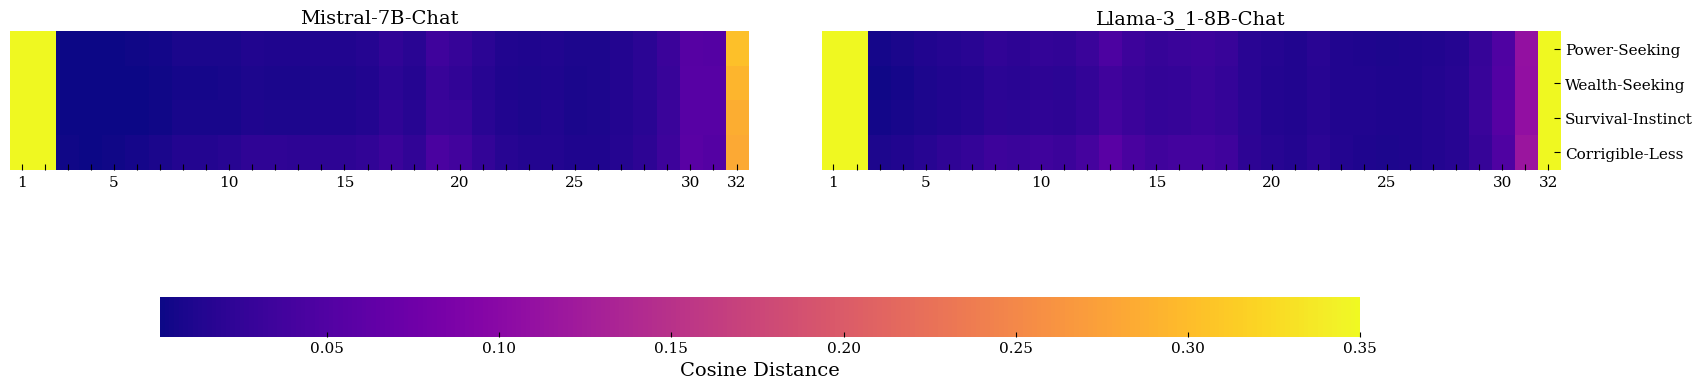

In [334]:
import matplotlib.pyplot as plt
import numpy as np
import re


# 2. BUILD THE DICTIONARY NOW THAT VARIABLES EXIST
RES = {
    'Power-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_power,
        'Llama-3_1-8B-Chat': llama_data_raw_power
    },
    'Wealth-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_weal,
        'Llama-3_1-8B-Chat': llama_data_raw_weal
    },
    'Survival-Instinct': {
        'Mistral-7B-Chat': mistral_data_raw_survival,
        'Llama-3_1-8B-Chat': llama_data_raw_survival
    },
    'Corrigible-Less': {
        'Mistral-7B-Chat': mistral_data_raw_corri,
        'Llama-3_1-8B-Chat': llama_data_raw_corri
    }
}

# 3. PARSE AND PLOT
def parse_means(raw_text):
    means = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            match = re.search(r'\[Mean:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
    return means

models = ['Mistral-7B-Chat', 'Llama-3_1-8B-Chat']
datasets = list(RES.keys())
num_layers = 32

model_heatmaps = {model: [] for model in models}

for dataset in datasets:
    for model in models:
        means = parse_means(RES[dataset][model])
        model_heatmaps[model].append(means)

for model in models:
    model_heatmaps[model] = np.array(model_heatmaps[model])

plt.rcParams.update({
    'font.family': 'serif', 
    'font.size': 11, 
    'axes.linewidth': 1.2,
    'xtick.direction': 'in', 
    'ytick.direction': 'in', 
    'grid.alpha': 0.3
})

fig, axes = plt.subplots(ncols=len(models), figsize=(20, 4))
if len(models) == 1:
    axes = [axes]

global_min = min(model_heatmaps[m].min() for m in models)
global_max = max(model_heatmaps[m].max() for m in models)

for i, (ax, model) in enumerate(zip(axes, models)):
    data = model_heatmaps[model]
    
    im = ax.imshow(data, aspect=1.5, cmap='plasma', vmin=global_min, vmax=0.35)

    
    ax.set_title(model, loc='center', fontweight='light')
    
    ax.set_yticks(np.arange(len(datasets)))
    
    if i == len(models) - 1:
        ax.set_yticklabels(datasets)
        ax.yaxis.tick_right()
        ax.tick_params(axis='y', length=4)
    else:
        ax.set_yticklabels([]) 
        ax.tick_params(axis='y', length=0) 

    ax.set_xticks(np.arange(num_layers))
    xtick_labels = []
    for j in range(num_layers):
        layer_num = j + 1
        if layer_num == 1 or layer_num % 5 == 0 or layer_num == 32:
            xtick_labels.append(str(layer_num))
        else:
            xtick_labels.append('')
            
    ax.set_xticklabels(xtick_labels)
    ax.tick_params(axis='x', length=4)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.1]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Cosine Distance')
cbar.outline.set_visible(False)

plt.subplots_adjust(bottom=0.2, wspace=0.1)
plt.show()